In [197]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import sweetviz
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
import warnings

In [198]:
warnings.filterwarnings('ignore')

In [199]:
df = pd.read_csv("C:\satvik\Desktop\Machine learning\insurance.csv")

In [200]:
df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [201]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# EDA

In [202]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [203]:
df.shape

(1338, 7)

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Visualization

In [205]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

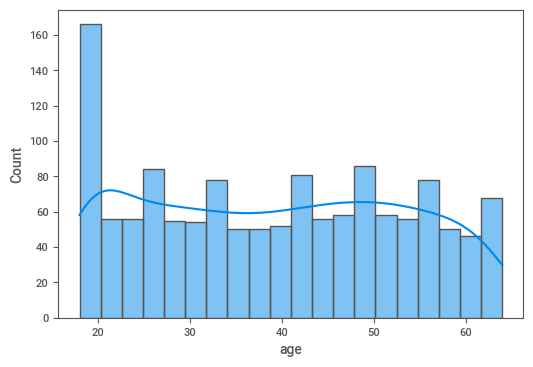

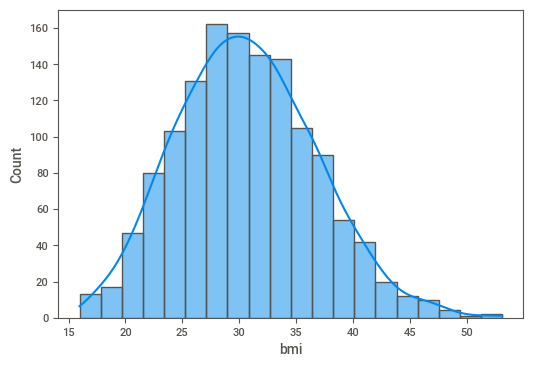

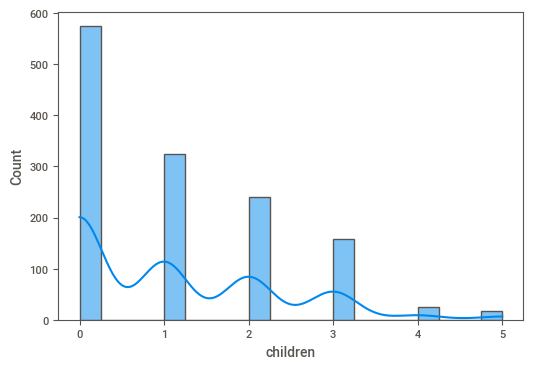

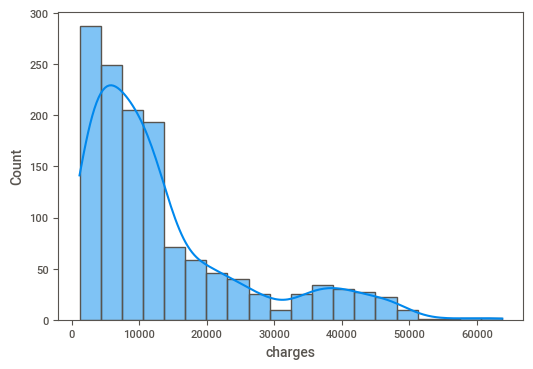

In [206]:
numeric_column = ['age', 'bmi', 'children',  'charges']

for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde = True, bins = 20)

In [207]:
# Generate EDA report
report = sv.analyze(df)

# Save report as HTML file
report.show_html("sweetviz_report.html")

                                             | | [  0%]   00:00 -> (? le

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


<Axes: xlabel='children', ylabel='count'>

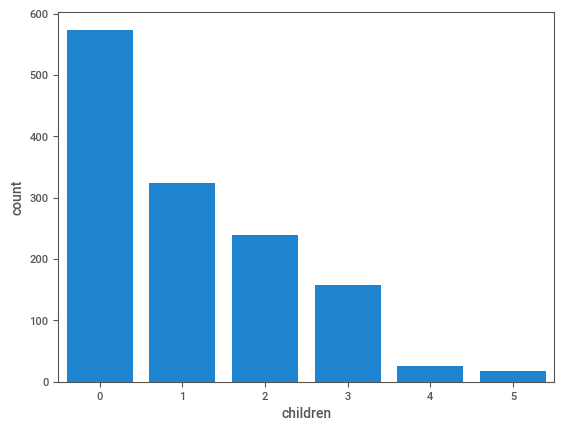

In [208]:
sns.countplot(x= df['children'])

<Axes: xlabel='sex', ylabel='count'>

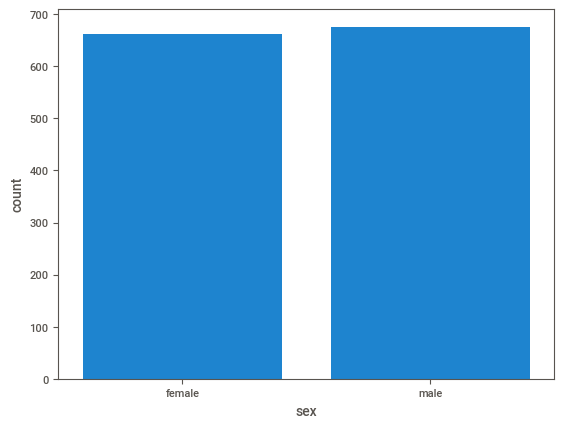

In [209]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

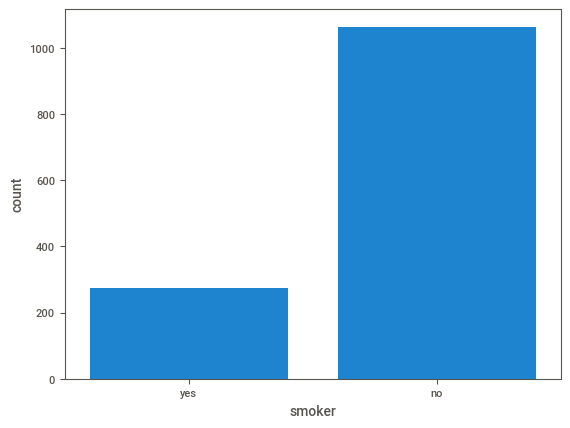

In [210]:
sns.countplot(x = df['smoker'])

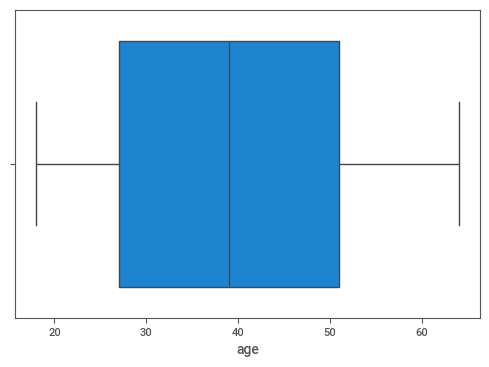

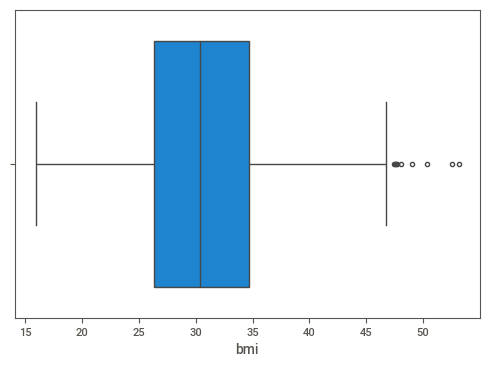

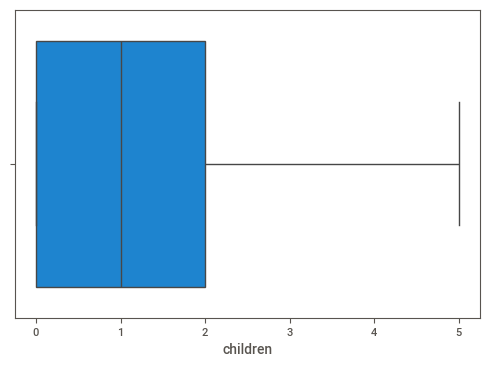

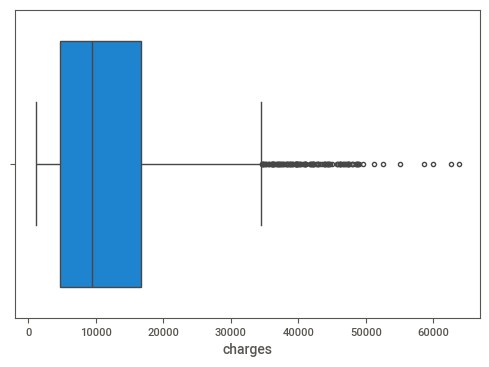

In [211]:
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.boxplot(x =df[col])

<Axes: >

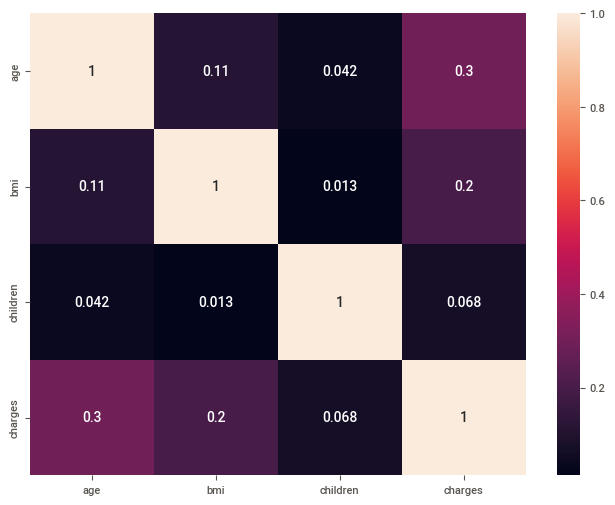

In [212]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only= True),annot = True)

# Data Cleaning and Preprocessing

In [213]:
df_clean = df.copy()

In [214]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [215]:
df_clean.drop_duplicates(inplace = True)

In [216]:
df_clean.shape

(1337, 7)

In [217]:
df_clean.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [218]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

## Label Encoding

In [219]:
df_clean['sex'] = df_clean['sex'].map({"male" : 0 ,"female": 1})

In [220]:
df_clean['smoker'] = df_clean['smoker'].map({"yes": 1, "no": 0})

In [221]:
df_clean.rename(columns={
    'sex' : 'is_female',
    'smoker' : 'is_smoker'
}, inplace = True)

In [222]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

## one hot Encoiding

In [223]:
df_clean = pd.get_dummies(df_clean, columns = ['region'],drop_first = True)

In [224]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [225]:
df_clean = df_clean.astype(int)

In [226]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


# Features Engineerin and extraction

<Axes: xlabel='bmi', ylabel='Count'>

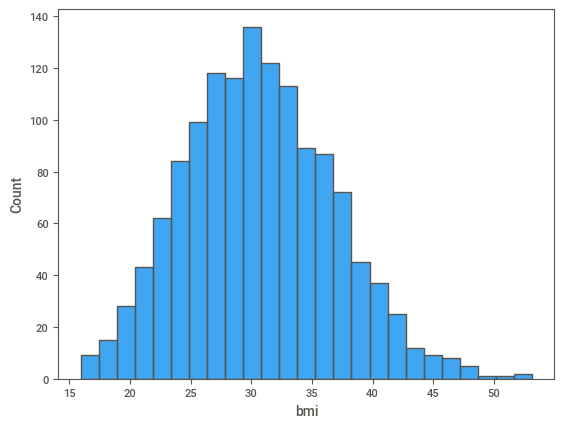

In [227]:
sns.histplot(df['bmi'])

In [228]:
df_clean['bmi_category'] = pd.cut(
    df_clean['bmi'], 
    bins = [0 , 18.5, 24.9, 29.9, float('inf')],
    labels= ['Underweight', 'Normal', 'Overweight', 'obese']
)

In [229]:
df_clean.head(3)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese


In [230]:
df_clean = pd.get_dummies(df_clean, columns = ['bmi_category'],drop_first = True)

In [231]:
df_clean.head(3)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True


In [232]:
df_clean = df_clean.astype(int)

In [233]:
df_clean.head(3)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1


## Standard Scaling

In [234]:
df_clean.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_obese'],
      dtype='object')

In [235]:
from sklearn.preprocessing import StandardScaler
cols =['age', 'bmi', 'children']
scaler = StandardScaler()

df_clean[cols] = scaler.fit_transform(df_clean[cols])

In [236]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


## Features Selections

In [237]:
from scipy.stats import pearsonr

In [238]:
selected_features = ['age', 'is_female', 'bmi', 'children', 'is_smoker', 
                     'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_obese']

correlation = {
    feature: pearsonr(df_clean[feature], df_clean['charges'])[0]
    for feature  in selected_features
    
}


correlation_df = pd.DataFrame(list(correlation.items()), columns = ['feature', 'Pearson correlation'])
correlation_df.sort_values(by = 'Pearson correlation' , ascending = False)

,feature,Pearson correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obese,0.200348
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,is_female,-0.058046
8,bmi_category_Normal,-0.104042


## Chi^2 Test

In [239]:
from scipy.stats import chi2_contingency
import pandas as pd

In [240]:
alpha = .5


df_clean['charges_bin'] = pd.qcut(df_clean['charges'], q=4)

In [241]:
alpha = 0.5

# Create bins for target variable
df_clean['charges_bin'] = pd.qcut(df_clean['charges'], q=4)

# categorical features list (make sure it's defined)
cat_features = [
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_Normal',
    'bmi_category_Overweight',
    'bmi_category_obese'
]

def chi_square_test(df, features, target):
    results = []
    
    for feature in features:
        table = pd.crosstab(df[feature], df[target])
        
        chi2, p, dof, exp = chi2_contingency(table)
        
        results.append((feature, chi2, p))
    
    return pd.DataFrame(results, columns=['feature', 'chi2_stat', 'p_value']) \
             .sort_values('p_value')

chi2_df = chi_square_test(df_clean, cat_features, 'charges_bin')

print(chi2_df)

                   feature   chi2_stat        p_value
1                is_smoker  848.219178  1.507478e-183
3         region_southeast   15.998167   1.134966e-03
0                is_female   10.258784   1.648974e-02
7       bmi_category_obese    8.515711   3.647336e-02
4         region_southwest    5.091893   1.651906e-01
6  bmi_category_Overweight    4.251490   2.355571e-01
5      bmi_category_Normal    3.708088   2.947595e-01
2         region_northwest    1.134240   7.688154e-01


In [242]:
final_df = df_clean[
    ['is_smoker', 'is_female', 'charges', 'bmi', 
     'bmi_category_obese', 'age', 'children', 'region_southeast']
]

In [243]:
final_df.head()

,is_smoker,is_female,charges,bmi,bmi_category_obese,age,children,region_southeast
0,1,1,16884,-0.517949,0,-1.440418,-0.909234,0
1,0,0,1725,0.462463,1,-1.511647,-0.079442,1
2,0,0,4449,0.462463,1,-0.799350,1.580143,1
3,0,0,21984,-1.334960,0,-0.443201,-0.909234,0
4,0,0,3866,-0.354547,0,-0.514431,-0.909234,0


## ML MODEL

In [244]:
## Split 30% Testing 70% Training 

In [245]:
from sklearn.model_selection import train_test_split

In [246]:
x = final_df.drop('charges',axis = 1)
y = final_df['charges']

In [247]:
 X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.33, random_state=42)

In [248]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Model Evaluation

In [249]:
y_pred = model.predict(X_test)

In [250]:
y_pred

array([ 7.92127799e+03,  4.92119238e+03,  1.44361661e+04,  3.18350564e+04,
        8.67581266e+03,  1.31496370e+04,  2.96706500e+04,  1.35753225e+03,
        1.11138061e+04,  9.75901566e+03,  1.09718507e+04,  3.19207448e+04,
        3.11479922e+04,  1.64631895e+04,  1.01416669e+04,  8.32071774e+03,
        5.33803897e+03,  3.20017531e+04,  3.02451537e+03,  3.68006468e+03,
        4.66358966e+03,  2.83775977e+04,  1.37230536e+04,  2.91390286e+04,
        3.12678786e+04,  6.11451613e+03,  3.45210883e+04,  3.77368630e+04,
        1.25138644e+04,  1.39034203e+04,  7.61698339e+03,  1.29803907e+04,
        2.19973352e+02,  1.13562442e+04,  3.73840277e+04,  1.34005302e+04,
        3.09042974e+03,  4.18337835e+03,  3.11602233e+04,  7.90007874e+03,
        6.09078081e+03,  2.99188465e+04,  3.46245387e+04,  1.31113974e+04,
        7.82128672e+03,  2.97515542e+03,  5.17030083e+03,  7.58441192e+03,
        3.39821208e+03,  1.01377275e+04,  7.54018550e+03,  1.05902298e+04,
        2.99695962e+04,  

In [264]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [265]:
n = X_test.shape[0]
p  = X_test.shape[1]

In [266]:
r2 = r2_score(y_test, y_pred)

In [267]:
r2

0.7737291785851907

In [275]:
Adjusted_r2 =1 - (1-r2)*(n-1)/(n-p-1)

In [276]:
Adjusted_r2

0.7700796492075326

In [277]:
mean_squared_error(y_test , y_pred)
mse

38488745.88218281

In [278]:
mae = mean_absolute_error(y_test, y_pred)
mae

4290.301483832133

In [282]:
y_train_pred = model.predict(X_train)


In [281]:
train_r2 = r2_score(y_train, y_train_pred)
train_r2

0.7396934796896987

In [283]:
train_AdjustedR2 = 1 - (1-train_r2)*(n-1)/(n-p-1)
train_AdjustedR2

0.7354949874266292

In [284]:
Train_mse = mean_squared_error(y_train , y_train_pred)
Train_mse

35066638.93987844

In [286]:
Train_mae = mean_absolute_error(y_train, y_train_pred)
Train_mae

4218.651125463779